In [ ]:
#Using stacked autoencoder
#Also trying on mprage data instead...

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Dependencies

#connect to google drive!
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 34.7 MB/s eta 0:00:00


In [3]:
#Dependencies
import pandas as pd
import shutil
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np

#if we resize
from PIL import Image

####Data Extraction

In [ ]:
prep_data()

In [ ]:
def prep_data(sites):
  #preparing data
  for site in sites:
    print("starting site: ", site)
    site_path = "drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/" + site
    pheno_csv = site_path + "/phenotypic_" + site + ".csv"
    csv = pd.read_csv(pheno_csv)
    rest_data_dir = "rest_data"

    os.makedirs("rest_data", exist_ok=True)

    #move to rest_data directory
    for index, row in csv.iterrows():
        sub_id = row['SUB_ID'] #patient id
        dx_group = row['DX_GROUP'] #diagnosis
        if dx_group == 1:
          dx_group = "ASD"
        else:
          dx_group = "CONTROL"

        # Build file path
        file_path = f"{site_path}/00{sub_id}/session_1/anat_1/mprage.nii.gz"
        dest_path = f"drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/{site}_{sub_id}_{dx_group}_mprage.nii.gz"
        # Move file
        if os.path.exists(file_path):
          if "OHSU/0050167" not in file_path and "OHSU/0050168" not in file_path and "UCLA_1/0051232" not in file_path and "UCLA_1/0051233" not in file_path and "UCLA_1/0051242" not in file_path and "UCLA_1/0051243/" not in file_path:
            shutil.copy(file_path, dest_path)

def explore_data(file_path):
  fmri_image = nib.load(file_path)
  image_data = fmri_image.get_fdata()
  print("Shape of example data: ", image_data.shape)

  #Axial View:
  #Slices are parallel to the plane of the face (looking at brain top down)
  #Corresponds to third dimension (z axis) --> z varies from 0 to 33
  #Taken at 150 different time points

  #AXIAL SLICE EXTRACTION
  x_shape = image_data.shape[0]
  y_shape = image_data.shape[1]
  z_shape = image_data.shape[2]
  t_shape = image_data.shape[3]

  print(x_shape, y_shape, z_shape, t_shape)

  x_positions = [0, int(x_shape/5),int(2*x_shape/5), int (x_shape/2), int(3*x_shape/5), int(4*x_shape/5), int(x_shape -1)]
  y_positions = [0, int(y_shape/5),int(2*y_shape/5),int (y_shape/2), int(3*y_shape/5), int(4*y_shape/5), int(y_shape -1)]
  z_positions = [0, int(z_shape/5),int(2*z_shape/5),int (z_shape/2), int(3*z_shape/5), int(4*z_shape/5), int(z_shape -1)]
  time_points = [0, int(t_shape/2), int(t_shape -1)]

  #Loop through to create subplots
  for z in z_positions:
      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      for i, t in enumerate(time_points):
          # Extract the axial slice at current Z and time point
          axial_slice = image_data[:, :, z, t]

          # Plot the axial slice
          axes[i].imshow(axial_slice, cmap="gray", origin="lower")
          axes[i].set_title(f"Axial Slice at Z={z}, Time Point={t}")

      # Adjust layout/show plot
      plt.tight_layout()
      plt.show()

  #Sagittal View:
  #Slices are parallel to midline, dividing brain in 2 halfs (side view)
  #Corresponds to first dimension (x axis) --> x varies from 0 to 63
  #Taken at 150 different time points

  #SAGITTAL SLICE EXTRACTION
  #Loop through to create subplots
  for x in x_positions:
      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      for i, t in enumerate(time_points):
          # Extract the sagittal slice at current X and time point
          axial_slice = image_data[x, :, :, t]

          # Plot the axial slice
          axes[i].imshow(axial_slice, cmap="gray", origin="lower")
          axes[i].set_title(f"Sagittal Slice at X={x}, Time Point={t}")

      # Adjust layout/show plot
      plt.tight_layout()
      plt.show()

  #Coronal view:
  #Slices are parallel to the face, dividing brain into anterior and posterior (front view)
  #Corresponds to second dimension (y axis) --> y varies from 0 to 63
  #Taken at 150 different time points


  #CORONAL SLICE EXTRACTION
  #Loop through to create subplots
  for y in y_positions:
      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      for i, t in enumerate(time_points):
          # Extract the coronal slice at current Y and time point
          axial_slice = image_data[:, y, :, t]

          # Plot the axial slice
          axes[i].imshow(axial_slice, cmap="gray", origin="lower")
          axes[i].set_title(f"Coronal Slice at Y={y}, Time Point={t}")

      # Adjust layout/show plot
      plt.tight_layout()
      plt.show()

#Loop through patients and save images for each view.
def get_Images():

  #make directories
  os.makedirs("content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_axial_images", exist_ok=True)
  os.makedirs("content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_coronal_images", exist_ok=True)
  os.makedirs("content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_sagittal_images", exist_ok=True)

  count = 1
  items =  os.listdir("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data")
  items_sorted = sorted(items)
  for img in items_sorted:
    print(img, count)
    if (".nii.gz") in img:
      path = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/" + img
      fmri_img = nib.load(path)
      image_data = fmri_img.get_fdata()

      sagittal_x = int((image_data.shape[0])/2)
      coronal_y = int((image_data.shape[1])/2)
      axial_z = int((image_data.shape[2])/2)
      time = int((image_data.shape[3])/2)

      axial_slice = image_data[:,:,axial_z,time]
      print(axial_slice.shape)
      plt.imshow(axial_slice)
      plt.savefig(f"content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_axial_images"/{img[:-7]}_axial_slice_{axial_z}.png")
      plt.close()

      sagittal_slice = image_data[sagittal_x,:,:,time]
      plt.imshow(sagittal_slice, origin="lower")
      plt.savefig(f"content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_sagittal_images/{img[:-7]}_sagittal_slice_{sagittal_x}.png")
      plt.close()

      coronal_slice = image_data[:,coronal_y,:,time]
      plt.imshow(coronal_slice)
      plt.savefig(f"content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_coronal_images"/{img[:-7]}_coronal_slice_{coronal_y}.png")
      plt.close()
      count+=1

def separate_data():
  #make directories
  os.makedirs("axial_images/control", exist_ok=True)
  os.makedirs("coronal_images/control", exist_ok=True)
  os.makedirs("sagittal_images/control", exist_ok=True)
  os.makedirs("axial_images/ASD", exist_ok=True)
  os.makedirs("coronal_images/ASD", exist_ok=True)
  os.makedirs("sagittal_images/ASD", exist_ok=True)


  #sort axial images
  for img in os.listdir("axial_images"):
    if "ASD" in img and "png" in img:
      file_path = "axial_images/" + img
      dest_path = "axial_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "axial_images/" + img
      dest_path = "axial_images/control/" + img
      shutil.move(file_path, dest_path)
  #sort coronal images
  for img in os.listdir("coronal_images"):
    if "ASD" in img and "png" in img:
      file_path = "coronal_images/" + img
      dest_path = "coronal_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "coronal_images/" + img
      dest_path = "coronal_images/control/" + img
      shutil.move(file_path, dest_path)
  #sort sagittal images
  for img in os.listdir("sagittal_images"):
    if "ASD" in img and "png" in img:
      file_path = "sagittal_images/" + img
      dest_path = "sagittal_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "sagittal_images/" + img
      dest_path = "sagittal_images/control/" + img
      shutil.move(file_path, dest_path)




In [ ]:
def preprocess_data():
  #sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD',
           #'TRINITY,' 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]
  sites = ['UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]
  #explore_data(file_path)
  #prep_data(sites)
  get_Images()
  #separate_data()

preprocess_data()

starting site:  UCLA_1
starting site:  UCLA_2
starting site:  LEUVEN_1
starting site:  LEUVEN_2
starting site:  UM_1
starting site:  UM_2
starting site:  PITT
starting site:  USM
starting site:  YALE


In [8]:
file_path = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/CALTECH_51456_ASD_mprage.nii.gz"


img = nib.load(file_path)
image_data = img.get_fdata()
print(img.shape)



sagittal_x = int((image_data.shape[0])/2)
coronal_y = int((image_data.shape[1])/2)
axial_z = int((image_data.shape[2])/2)

axial_slice = image_data[:,:,0]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()


axial_slice = image_data[:,:,75]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()


print("here 125")
axial_slice = image_data[:,:,125]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()

print("here 150")
axial_slice = image_data[:,:,150]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()

print("here 175")
axial_slice = image_data[:,:,175]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()

print("here 200")
axial_slice = image_data[:,:,200]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()


print("here 225")
axial_slice = image_data[:,:,225]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()


print("here x=0")
axial_slice = image_data[0,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()

print("here x=60")
axial_slice = image_data[60,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here x=80")
axial_slice = image_data[80,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here x=100")
axial_slice = image_data[100,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here x=120")
axial_slice = image_data[120,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here x=140")
axial_slice = image_data[140,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here x=160")
axial_slice = image_data[160,:,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()

print("here y=0")
axial_slice = image_data[:,0,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here y=75")
axial_slice = image_data[:,75,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here y=125")
axial_slice = image_data[:,125,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here y=150")
axial_slice = image_data[:,150,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here y=175")
axial_slice = image_data[:,175,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here y=200")
axial_slice = image_data[:,200,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()
print("here y=255")
axial_slice = image_data[:,225,:]
print(axial_slice.shape)
plt.imshow(axial_slice)
#plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:

def resize_image(image_path, target_size=(256, 256)):
  img = Image.open(image_path)
  img_resized = img.resize(target_size, Image.LANCZOS)
  return img_resized

def process_and_move_images(source_dir, target_dir):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    for filename in os.listdir(source_dir):
        if filename.endswith(".png"):  # Process only .png files
            source_path = source_dir + "/" + filename
            target_path = target_dir + "/" + filename

            # Resize image
            resized_image = resize_image(source_path)

            # Save resized image to target directory
            resized_image.save(target_path)
            #print(f"Resized and moved: {filename}")


# Example usage
views = ["axial", "coronal", "sagittal"]
for view in views:
  source_directory = f"/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_{view}_images/control"
  target_directory = f"/content/ABIDE_I_rest_{view}_images_resized/control"
  process_and_move_images(source_directory, target_directory)
  source_directory = f"/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_{view}_images/ASD"
  target_directory = f"/content/ABIDE_I_rest_{view}_images_resized/ASD"
  process_and_move_images(source_directory, target_directory)
  print(f"{view} done")

####Explore Data: Determining best cuts

Chose middle for each in the end... potentially worth exploring other slices?

In [ ]:
#Shape of site CALTECH data:  (64, 64, 34, 150)
#explore_data("/content/rest_data/CALTECH_51456_ASD_rest.nii.gz")
#best cuts: z=17, x=32, y=32, t=75

#shape of site CMU data: (64 64 28 240)
#explore_data("/content/rest_data/CMU_50642_ASD_rest.nii.gz")
#best cuts: z=14, x=32, y=32, t=120


#Shape of site KKI data:  (96, 96, 47, 156)
#explore_data("/content/rest_data/KKI_50772_CONTROL_rest.nii.gz")
#best cuts: z=23, x=48, y=48, t=78


#Shape of site MAX_MUN data: 64 64 28 120
#explore_data("/content/rest_data/MAX_MUN_51318_ASD_rest.nii.gz")
#best cuts: z=14, x=32, y=32, t=60


#Shape of site OLIN data: 64 64 29 210
#explore_data("/content/rest_data/OLIN_50118_ASD_rest.nii.gz")
#best cuts: z=14, x=32, y=32, t=105




#### Visualize a sample AXIAL ASD/Control from each site

In [ ]:
def explore_sites():
  sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD',
           'TRINITY', 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]

  items = os.listdir("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_data")
  items = sorted(items)

  for image in items:
        file_path = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_data/" + image
        fmri_image = nib.load(file_path)
        image_data = fmri_image.get_fdata()

        sagittal_x = int((image_data.shape[0])/2)
        coronal_y = int((image_data.shape[1])/2)
        axial_z = int((image_data.shape[2])/2)
        time = int((image_data.shape[3])/2)

        #print(f"Shape of {site} data: ", image_data.shape)

        axial_slice = image_data[:,:,axial_z,time]
        #print(f"Shape of {site} axial slice: ", axial_slice.shape)
        resized_axial_slice = np.array(Image.fromarray(axial_slice).resize((128,128), Image.LANCZOS))
        # Plot and save the resized axial slice
        #print("Resized shape of {site} axial slice: ", resized_axial_slice.shape)
        plt.imshow(resized_axial_slice)  # Use cmap='gray' for grayscale images
        plt.axis('off')  # Turn off axis
        plt.savefig(f"axial_images_128/{image[:-7]}_axial_slice_{axial_z}.png", bbox_inches='tight')
        plt.close()  # Close the figure


        sagittal_slice = image_data[sagittal_x,:,:,time]
        #print(f"Shape of {site} sagittal slice: ", sagittal_slice.shape)
        resized_sagittal_slice = np.array(Image.fromarray(sagittal_slice).resize((128,128), Image.LANCZOS))
        #print("Resized shape of {site} sagittal slice: ", resized_sagittal_slice.shape)
        plt.imshow(resized_sagittal_slice)  # Use cmap='gray' for grayscale images
        plt.axis('off')  # Turn off axis
        plt.savefig(f"sagittal_images_128/{image[:-7]}_sagittal_slice_{sagittal_x}.png", bbox_inches='tight')
        plt.close()  # Close the figure

        coronal_slice = image_data[:,coronal_y,:,time]
        #print(f"Shape of {site} coronal slice: ", coronal_slice.shape)
        resized_coronal_slice = np.array(Image.fromarray(coronal_slice).resize((128,128), Image.LANCZOS))
        #print("Resized shape of {site} coronal slice: ", resized_coronal_slice.shape)
        plt.imshow(resized_coronal_slice)  # Use cmap='gray' for grayscale images
        plt.axis('off')  # Turn off axis
        plt.savefig(f"coronal_images_128/{image[:-7]}_coronal_slice_{coronal_y}.png", bbox_inches='tight')
        plt.close()  # Close the figure

        print(f"{image} done")

explore_sites()
#resize all
'''
Shape of CALTECH axial slice:  (64, 64)
Shape of KKI axial slice:  (96, 96)
Shape of OLIN axial slice:  (64, 64)
Shape of MAX_MUN axial slice:  (64, 64)
Shape of CMU axial slice:  (64, 64)
Shape of NYU axial slice:  (64, 80)
Shape of OHSU axial slice:  (64, 64)
Shape of SDSU axial slice:  (64, 64)
Shape of SBL axial slice:  (80, 80)
Shape of STANFORD axial slice:  (64, 64)
Shape of TRINITY axial slice:  (80, 80)
Shape of UCLA_1 axial slice:  (64, 64)
Shape of UCLA_2 axial slice:  (64, 64)
Shape of LEUVEN_1 axial slice:  (64, 64)
Shape of LEUVEN_2 axial slice:  (64, 64)
Shape of UM_1 axial slice:  (64, 64)
Shape of UM_2 axial slice:  (64, 64)
Shape of PITT axial slice:  (64, 64)
Shape of USM axial slice:  (64, 64)
Shape of YALE axial slice:  (64, 64)
'''
#Axial - do 96 by 96

'''
Shape of CALTECH sagittal slice:  (64, 34)
Shape of KKI sagittal slice:  (96, 47)
Shape of OLIN sagittal slice:  (64, 29)
Shape of MAX_MUN sagittal slice:  (64, 28)
Shape of CMU sagittal slice:  (64, 28)
Shape of NYU sagittal slice:  (80, 33)
Shape of OHSU sagittal slice:  (64, 36)
Shape of SDSU sagittal slice:  (64, 42)
Shape of SBL sagittal slice:  (80, 38)
Shape of STANFORD sagittal slice:  (64, 29)
Shape of TRINITY sagittal slice:  (80, 38)
Shape of UCLA_1 sagittal slice:  (64, 34)
Shape of UCLA_2 sagittal slice:  (64, 34)
Shape of LEUVEN_1 sagittal slice:  (64, 32)
Shape of LEUVEN_2 sagittal slice:  (64, 32)
Shape of UM_1 sagittal slice:  (64, 40)
Shape of UM_2 sagittal slice:  (64, 40)
Shape of PITT sagittal slice:  (64, 29)
Shape of USM sagittal slice:  (64, 40)
Shape of YALE sagittal slice:  (64, 34)
'''

'''
Shape of CALTECH coronal slice:  (64, 34)
Shape of KKI coronal slice:  (96, 47)
Shape of OLIN coronal slice:  (64, 29)
Shape of MAX_MUN coronal slice:  (64, 28)
Shape of CMU coronal slice:  (64, 28)
Shape of NYU coronal slice:  (64, 33)
Shape of OHSU coronal slice:  (64, 36)
Shape of SDSU coronal slice:  (64, 42)
Shape of SBL coronal slice:  (80, 38)
Shape of STANFORD coronal slice:  (64, 29)
Shape of TRINITY coronal slice:  (80, 38)
Shape of UCLA_1 coronal slice:  (64, 34)
Shape of UCLA_2 coronal slice:  (64, 34)
Shape of LEUVEN_1 coronal slice:  (64, 32)
Shape of LEUVEN_2 coronal slice:  (64, 32)
Shape of UM_1 coronal slice:  (64, 40)
Shape of UM_2 coronal slice:  (64, 40)
Shape of PITT coronal slice:  (64, 29)
Shape of USM coronal slice:  (64, 40)
Shape of YALE coronal slice:  (64, 34)
'''


In [ ]:
def separate_data():
  #make directories
  os.makedirs("axial_images_128/control", exist_ok=True)
  os.makedirs("coronal_images_128/control", exist_ok=True)
  os.makedirs("sagittal_images_128/control", exist_ok=True)
  os.makedirs("axial_images_128/ASD", exist_ok=True)
  os.makedirs("coronal_images_128/ASD", exist_ok=True)
  os.makedirs("sagittal_images_128/ASD", exist_ok=True)


  #sort axial images
  for img in os.listdir("axial_images_128"):
    if "ASD" in img and "png" in img:
      file_path = "axial_images_128/" + img
      dest_path = "axial_images_128/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "axial_images_128/" + img
      dest_path = "axial_images_128/control/" + img
      shutil.move(file_path, dest_path)
  #sort coronal images
  for img in os.listdir("coronal_images_128"):
    if "ASD" in img and "png" in img:
      file_path = "coronal_images_128/" + img
      dest_path = "coronal_images_128/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "coronal_images_128/" + img
      dest_path = "coronal_images_128/control/" + img
      shutil.move(file_path, dest_path)
  #sort sagittal images
  for img in os.listdir("sagittal_images_128"):
    if "ASD" in img and "png" in img:
      file_path = "sagittal_images_128/" + img
      dest_path = "sagittal_images_128/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "sagittal_images_128/" + img
      dest_path = "sagittal_images_128/control/" + img
      shutil.move(file_path, dest_path)
separate_data()

In [ ]:
def visualizeSamplesFromSites(orientation):
  print("ORIENTATION: ", orientation)
  sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD',
           'TRINITY', 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]
  for site in sites:
    directory_ASD = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_" + orientation + "_images/ASD/"
    directory_control = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_" + orientation + "_images/control/"
    print("SITE: ", site)
    #print("ASD IMAGE: ")
    for image in os.listdir(directory_ASD):
      if site in image and site == "CALTECH":
          file_path = directory_ASD + image
          img = mpimg.imread(file_path)
          plt.imshow(img)
          plt.axis('off')
          plt.title('ASD Image')  # Add a title if desired
          plt.show()

          print("ASD Image Shape:", img.shape)
          #print()
          break
    #print("CONTROL IMAGE: ")
    for image in os.listdir(directory_control):
      if site in image:
          file_path = directory_control + image
          img = mpimg.imread(file_path)
          #plt.imshow(img)
          #plt.axis('off')
          #plt.title('ASD Image')  # Add a title if desired
          #plt.show()

          print("Control Image Shape:", img.shape)
          #print()
          break
    print()
    print()


#axial size: (480, 640, 4)
#visualizeSamplesFromSites("axial")
#coronal size: 480, 640, 4
#visualizeSamplesFromSites("coronal")
visualizeSamplesFromSites("sagittal")


### Model:

In [ ]:
#dependencies
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
import numpy as np
import os
from PIL import Image

import pandas as pd
import shutil
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

#if we resize
from PIL import Image

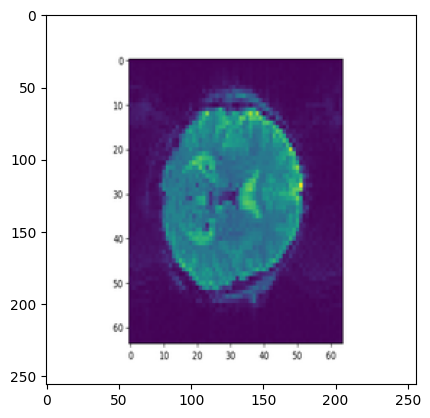

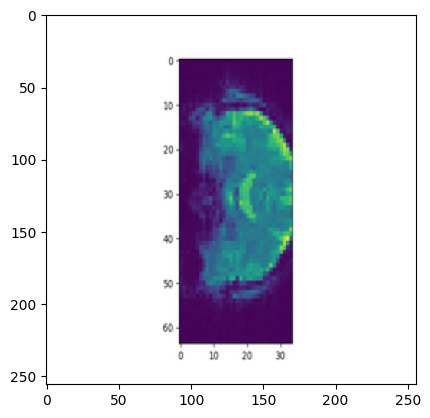

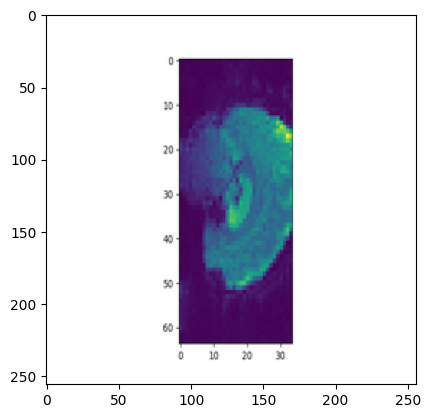

In [ ]:
img = Image.open("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_axial_images_resized/ASD/CALTECH_51456_ASD_rest_axial_slice_17.png")
plt.imshow(img)
plt.show()
img = Image.open("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_coronal_images_resized/ASD/CALTECH_51456_ASD_rest_coronal_slice_32.png")
plt.imshow(img)
plt.show()
img = Image.open("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_sagittal_images_resized/ASD/CALTECH_51456_ASD_rest_sagittal_slice_32.png")
plt.imshow(img)
plt.show()

In [ ]:

def getImageNames(directory):
  images = []
  for filename in os.listdir(directory):
        if filename.endswith(".png"):
          path = directory + "/" + filename
          images.append(path)
  return np.array(images)

def getSets(control_dir, autistic_dir):
  X_control = getImageNames(control_dir)
  X_autistic = getImageNames(autistic_dir)
  # Split control data into training and validation sets
  X_train_control, X_test_control = train_test_split(X_control, test_size=0.2, random_state=42)
  X_train_control, X_val_control = train_test_split(X_train_control, test_size=0.2, random_state=42)
  X_train_ASD_not_to_use, X_test_ASD = train_test_split(X_autistic, test_size=0.2, random_state=42)
  print("X_train_control of size: ", X_train_control.shape)
  print("X_val_control of size: ", X_val_control.shape)
  print("X_test_control of size: ", X_test_control.shape)
  print("X_test_ASD of size: ", X_test_ASD.shape)
  return X_train_control, X_val_control, X_test_control, X_test_ASD

#Visualize sets - just to see what data looks like

def visualizeData(set, setName):
  print("Visualizing set: ", setName)

  fig, axes = plt.subplots(1, len(set), figsize=(15, 3))

  for i, filename in enumerate(set):
      img = Image.open(filename)
      axes[i].imshow(img)
      axes[i].axis('off')

  plt.tight_layout()
  plt.show()

def load_and_preprocess_images(set):
    images = []
    for filename in set:
      img = load_img(filename)
      img = np.array(img) / 255.0
      images.append(img)
    return np.array(images)
# Function to plot original, reconstructed, and subtraction images
def plot_images(original, reconstructed, title):
    fig, axes = plt.subplots(3, len(original), figsize=(15, 6))

    # Plot original images
    for i in range(len(original)):
        axes[0, i].imshow(original[i], cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

    # Plot reconstructed images
    for i in range(len(reconstructed)):
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    # Plot subtraction (difference) images
    for i in range(len(original)):
        subtracted_img = np.abs(original[i] - reconstructed[i])
        axes[2, i].imshow(subtracted_img, cmap='gray')
        axes[2, i].set_title('Difference')
        axes[2, i].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_image_differences(image_1_path, image_2_path):
  # Load images
  img1 = Image.open(image_1_path)
  img2 = Image.open(image_1_path)

  # Convert images to numpy arrays and subtract
  img1_array = np.array(img1)
  img2_array = np.array(img2)
  subtracted_img = np.abs(img1_array - img2_array)

  # Plot original images and subtraction result
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))

  # Plot first image
  axes[0].imshow(img1_array, cmap='gray')
  axes[0].set_title('Image 1')
  axes[0].axis('off')

  # Plot second image
  axes[1].imshow(img2_array, cmap='gray')
  axes[1].set_title('Image 2')
  axes[1].axis('off')

  # Plot subtraction result
  axes[2].imshow(subtracted_img, cmap='gray')
  axes[2].set_title('Subtraction Result')
  axes[2].axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense


def autoencoder(X_train_control, X_val_control, X_test_control, X_test_ASD):
  input_img = Input(shape=(256, 256, 3))  # adjust if we resize

  # Encoder
  encoded = Dense(64, activation='relu')(input_img) # Additional layer with 6 neurons
  encoded = Dense(32, activation='relu')(encoded)

  # Decoder
  decoded = Dense(64, activation='relu')(encoded) # Additional layer with 6 neurons
  decoded = Dense(3, activation='sigmoid')(decoded)

  # Autoencoder model
  stacked_AE = Model(input_img, decoded)

  #compile
  stacked_AE.compile(optimizer='adam', loss='mse')

  history = stacked_AE.fit(X_train_control, X_train_control, epochs=10,
                           batch_size=32, validation_data=(X_val_control, X_val_control))

  #plot model history
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Train', 'Validation'], loc='upper right')
  plt.show()


  #predict on test data
  reconstructed_control = stacked_AE.predict(X_test_control)
  reconstructed_ASD = stacked_AE.predict(X_test_ASD)

  # Calculate MSE for control and ASD MRIs
  mse_control = np.mean(np.square(reconstructed_control - X_test_control))
  mse_ASD = np.mean(np.square(reconstructed_ASD - X_test_ASD))

  print(f"MSE on test set (control MRIs): {mse_control}")
  print(f"MSE on test set (ASD MRIs): {mse_ASD}")

  #VISUALIZE RECONSTRUCTIONS
  # Select a few examples from X_test_control and X_test_ASD
  num_examples = 5  # Number of examples to visualize
  examples_control = X_test_control[:num_examples]
  examples_ASD = X_test_ASD[:num_examples]

  # Plot examples for control MRIs
  plot_images(examples_control, reconstructed_control[:num_examples], title='Control MRI Reconstruction')

  # Plot examples for ASD MRIs
  plot_images(examples_ASD, reconstructed_ASD[:num_examples], title='ASD MRI Reconstruction')

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/10
12/12 [==============================] - 53s 4s/step - loss: 0.1484 - val_loss: 0.1267
Epoch 2/10
12/12 [==============================] - 49s 4s/step - loss: 0.1125 - val_loss: 0.0942
Epoch 3/10
12/12 [==============================] - 47s 4s/step - loss: 0.0831 - val_loss: 0.0717
Epoch 4/10
12/12 [==============================] - 49s 4s/step - loss: 0.0643 - val_loss: 0.0561
Epoch 5/10
12/12 [==============================] - 51s 4s/step - loss: 0.0483 - val_loss: 0.0395
Epoch 6/10
12/12 [==============================] - 49s 4s/step - loss: 0.0321 - val_loss: 0.0240
Epoch 7/10
12/12 [==============================] - 47s 4s/step - loss: 0.0180 - val_loss: 0.0125


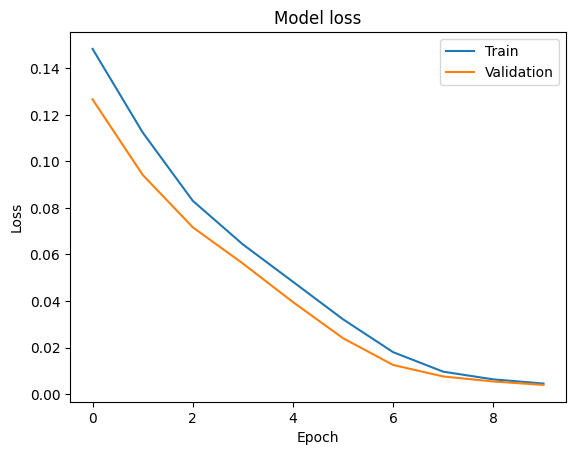

4/4 [==============================] - 4s 1s/step
MSE on test set (control MRIs): 0.0037279052873784298
MSE on test set (ASD MRIs): 0.003776800645177169


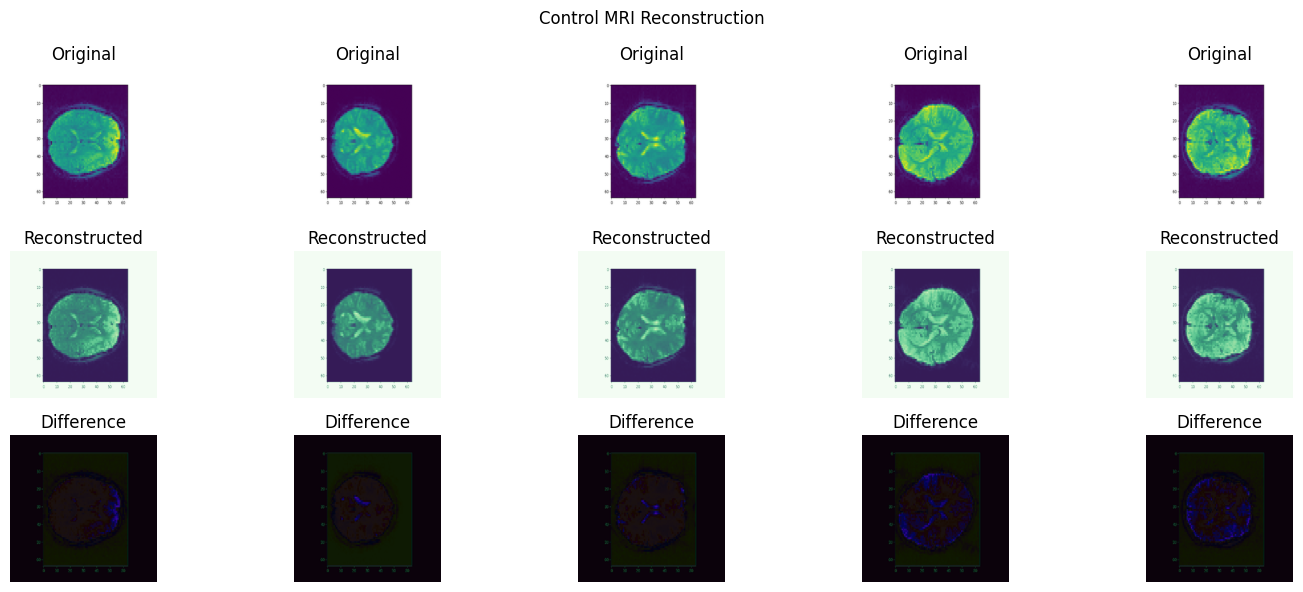

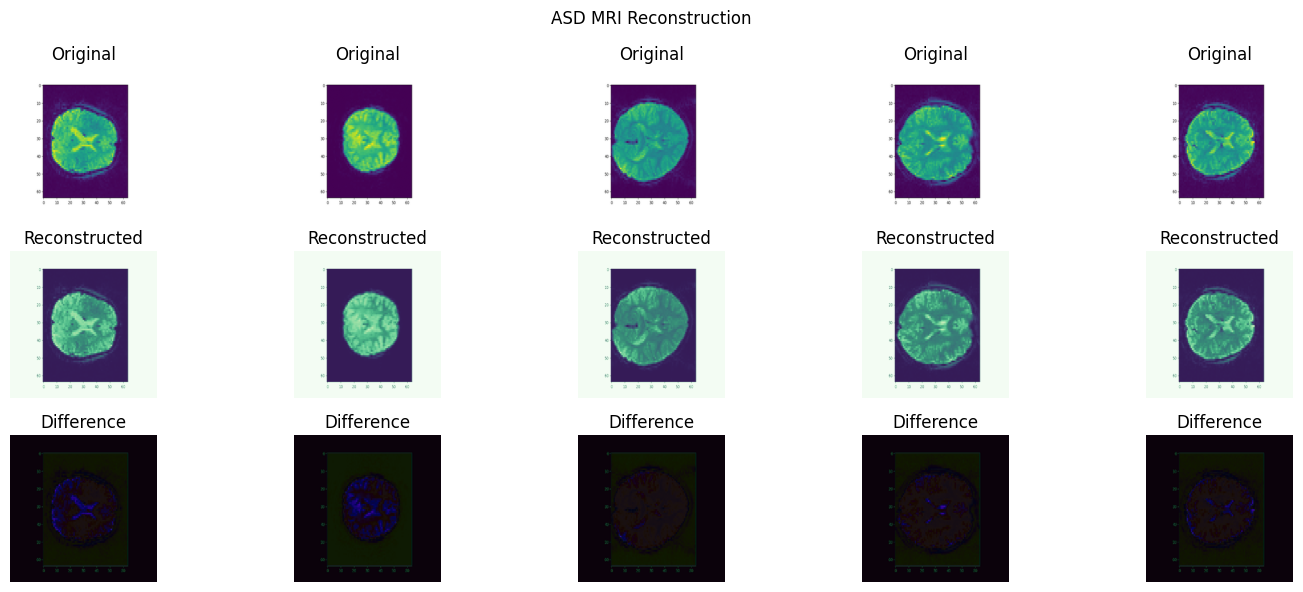

In [ ]:
def runModel(view):
  control_dir = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_axial_images_resized/control"
  autistic_dir = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_axial_images_resized/ASD"
  X_train_control, X_val_control, X_test_control, X_test_ASD = getSets(control_dir, autistic_dir)

  #visualizeData(X_test_control, "X_test_control")
  #visualizeData(X_test_ASD, "X_test_ASD")

  #print("Plotting an example difference between control and ASD")
  #plot_image_differences(X_test_control[0], X_test_ASD[0])

  X_train_control = load_and_preprocess_images(X_train_control)
  X_val_control = load_and_preprocess_images(X_val_control)
  X_test_ASD = load_and_preprocess_images(X_test_ASD)
  X_test_control = load_and_preprocess_images(X_test_control)
  print("X_train_control images shape: ", X_train_control.shape)
  print("X_val_control images shape: ", X_val_control.shape)
  print("X_test_control images shape: ", X_test_control.shape)
  print("X_test_ASD images shape: ", X_test_ASD.shape)

  autoencoder(X_train_control, X_val_control, X_test_control, X_test_ASD)


runModel("axial")

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/10
12/12 [==============================] - 50s 4s/step - loss: 0.1406 - val_loss: 0.1222
Epoch 2/10
12/12 [==============================] - 48s 4s/step - loss: 0.1102 - val_loss: 0.0962
Epoch 3/10
12/12 [==============================] - 51s 4s/step - loss: 0.0889 - val_loss: 0.0827
Epoch 4/10
12/12 [==============================] - 49s 4s/step - loss: 0.0775 - val_loss: 0.0719
Epoch 5/10
12/12 [==============================] - 48s 4s/step - loss: 0.0655 - val_loss: 0.0581
Epoch 6/10
12/12 [==============================] - 48s 4s/step - loss: 0.0509 - val_loss: 0.0428
Epoch 7/10
12/12 [==============================] - 50s 4s/step - loss: 0.0357 - val_loss: 0.0278


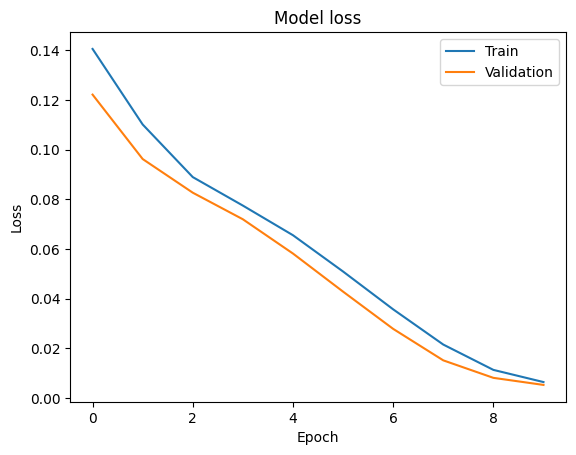

4/4 [==============================] - 4s 1s/step
MSE on test set (control MRIs): 0.004909188629746521
MSE on test set (ASD MRIs): 0.004958786735437246


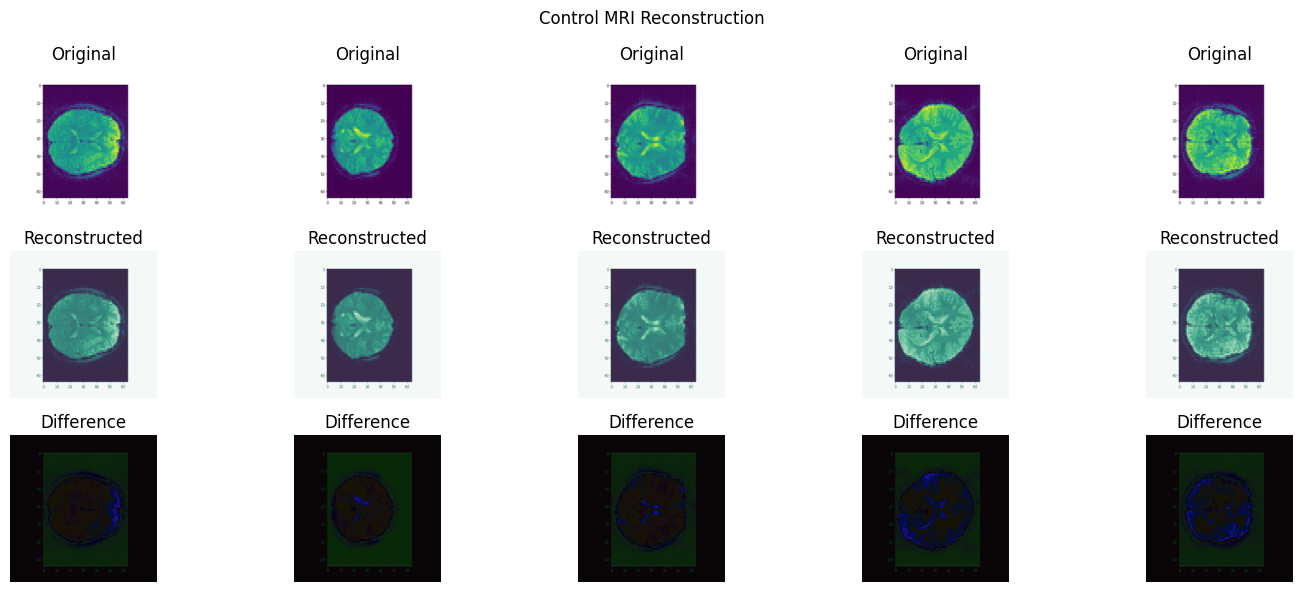

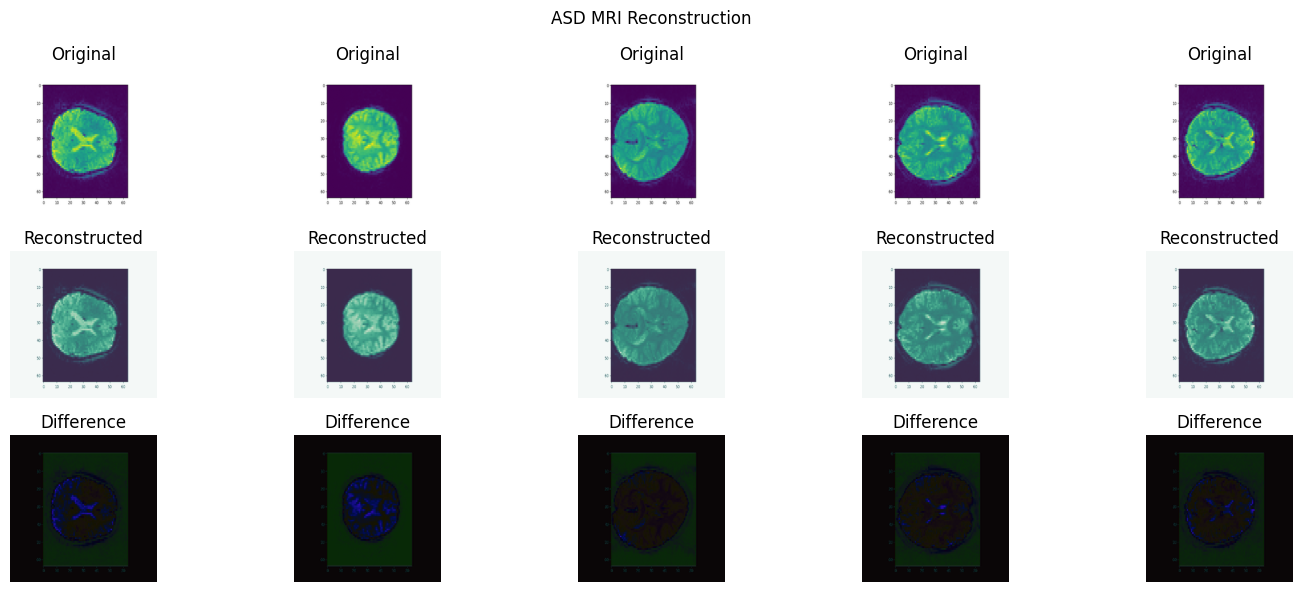

In [ ]:
runModel("sagittal")

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/10
12/12 [==============================] - 51s 4s/step - loss: 0.1374 - val_loss: 0.1167
Epoch 2/10
12/12 [==============================] - 49s 4s/step - loss: 0.1036 - val_loss: 0.0891
Epoch 3/10
12/12 [==============================] - 48s 4s/step - loss: 0.0817 - val_loss: 0.0751
Epoch 4/10
12/12 [==============================] - 50s 4s/step - loss: 0.0695 - val_loss: 0.0638
Epoch 5/10
12/12 [==============================] - 48s 4s/step - loss: 0.0580 - val_loss: 0.0522
Epoch 6/10
12/12 [==============================] - 48s 4s/step - loss: 0.0474 - val_loss: 0.0428
Epoch 7/10
12/12 [==============================] - 54s 4s/step - loss: 0.0376 - val_loss: 0.0321


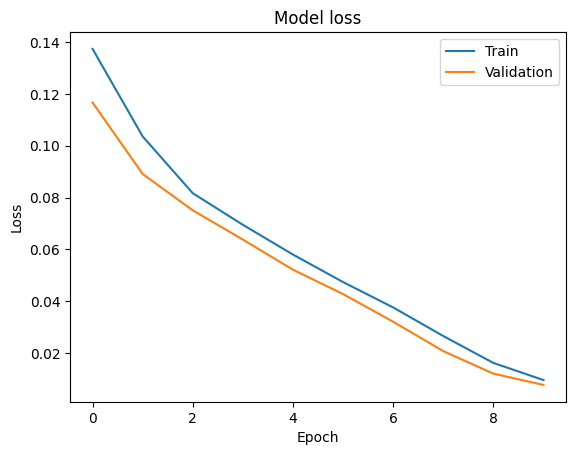

4/4 [==============================] - 4s 1s/step
MSE on test set (control MRIs): 0.007466276207231077
MSE on test set (ASD MRIs): 0.007461546078496216


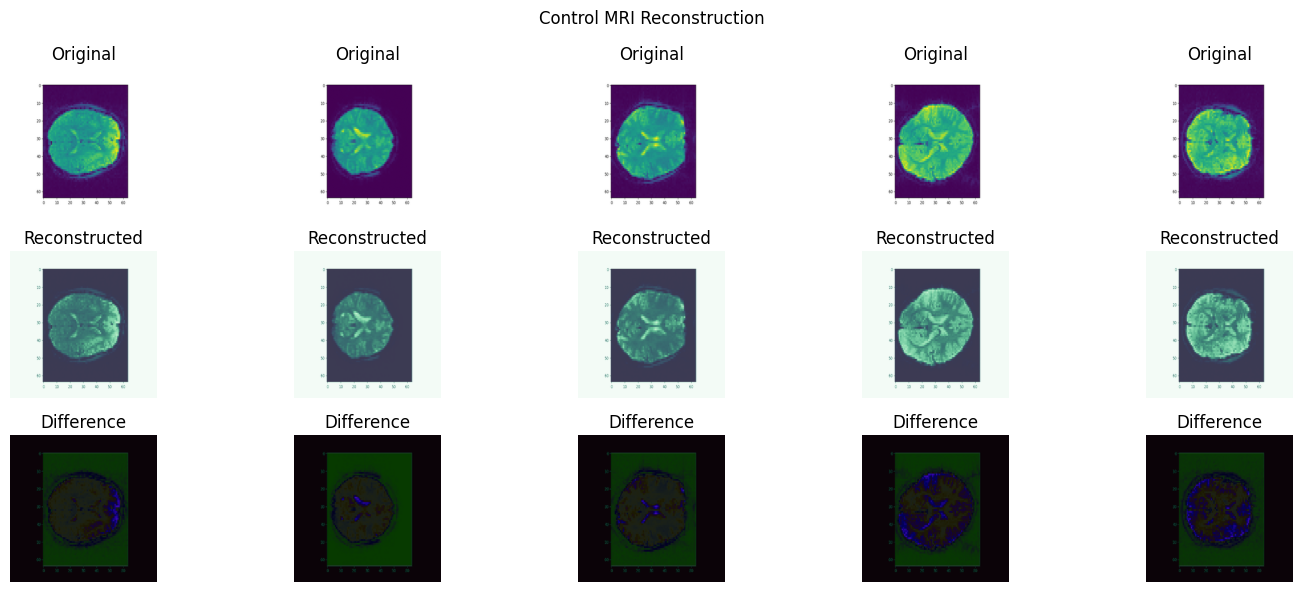

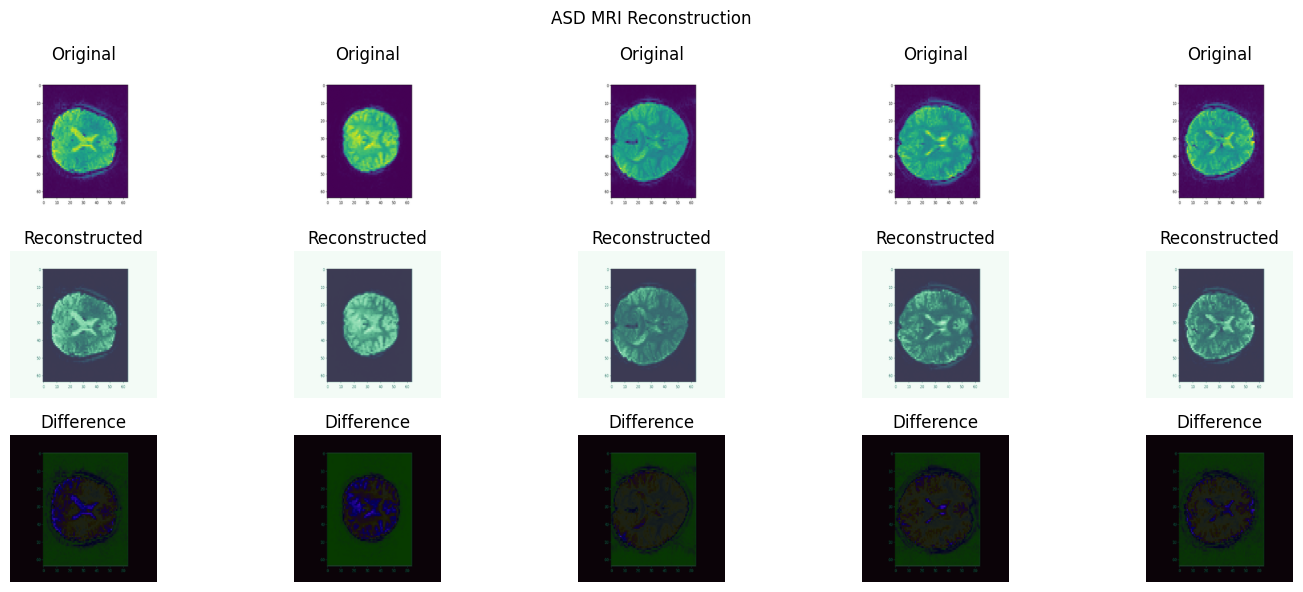

In [ ]:
runModel("coronal")

Questions:
- Look at image subtraction
- Should I try working with nii.gz instead of png?
- or mprage data?
- Resizing???


Need bigger dataset STILL
Need to do model history still
